<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 21: Non-Parametric Statistics & Time Series Analysis
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 19

This notebook covers:
1. **Non-Parametric Tests**: Friedman Test and Spearman Rank Correlation.
2. **Time Series Foundations**: Superposition, Trend, and Seasonality.
3. **Preprocessing**: Interpolation and Smoothing.
4. **Signal Analysis**: Autocorrelation, Detrending, and Cross-correlation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Set visual style
sns.set_theme(style="whitegrid")

## 1. Non-Parametric Statistics
### 1.1 The Friedman Test
The **Friedman Test** is the non-parametric equivalent of a repeated-measures ANOVA. It is used when you have **related samples** (e.g., the same site measured under different conditions) and the data is not normally distributed. It ranks data **within each block** (site) rather than across the whole dataset.

**Example Case:** Testing soil water content across three different treatments in six different field blocks.

Friedman Statistic: 6.3333
P-value: 0.0421


/tmp/ipykernel_7740/3870055465.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Treatment', y='Water Content', data=df_melted, palette='Set2')


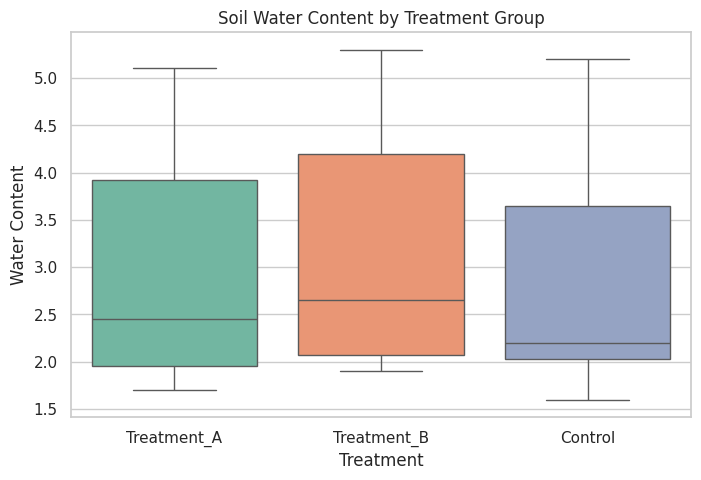

In [2]:
# Data: Water content (g/100g) in 6 blocks for 3 treatments
data = {
    'Treatment_A': [2.5, 1.8, 4.4, 2.4, 5.1, 1.7],
    'Treatment_B': [2.7, 1.9, 4.7, 2.6, 5.3, 1.9],
    'Control':     [2.1, 2.0, 4.1, 2.3, 5.2, 1.6]
}
df_friedman = pd.DataFrame(data)

# Perform Friedman Test
stat, p = stats.friedmanchisquare(df_friedman['Treatment_A'],
                                   df_friedman['Treatment_B'],
                                   df_friedman['Control'])

print(f"Friedman Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Visualize with a boxplot
df_melted = df_friedman.melt(var_name='Treatment', value_name='Water Content')
plt.figure(figsize=(8, 5))
sns.boxplot(x='Treatment', y='Water Content', data=df_melted, palette='Set2')
plt.title("Soil Water Content by Treatment Group")
plt.show()

### 1.2 Spearman Rank Correlation ($r_s$)
Spearman’s correlation measures the **monotonic** relationship between variables. It is more robust than Pearson because it uses the **ranks** of the data, allowing it to detect non-linear relationships that Pearson might miss.

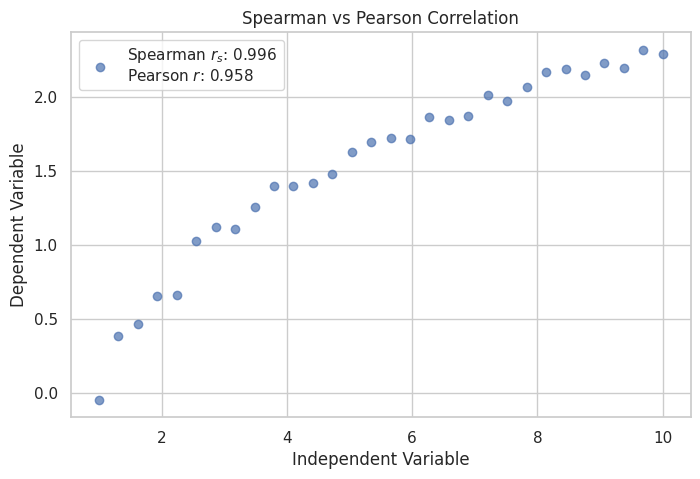

In [3]:
# Generate data: A perfect monotonic relationship that is non-linear
x = np.linspace(1, 10, 30)
y = np.log(x) + np.random.normal(0, 0.05, 30) # Logarithmic trend with slight noise

# Calculate correlations
rho_s, _ = stats.spearmanr(x, y)
r_p, _ = stats.pearsonr(x, y)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label=f'Spearman $r_s$: {rho_s:.3f}\nPearson $r$: {r_p:.3f}')
plt.title("Spearman vs Pearson Correlation")
plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
plt.legend()
plt.show()

## 2. Time Series Analysis
### 2.1 Superposition and the Keeling Curve
A time series is often a combination (superposition) of:
* **Trend ($T_t$):** Long-term increase or decrease.
* **Seasonality ($S_t$):** Repeating cycles (e.g., annual climate cycles).
* **Noise ($R_t$):** Random fluctuations.

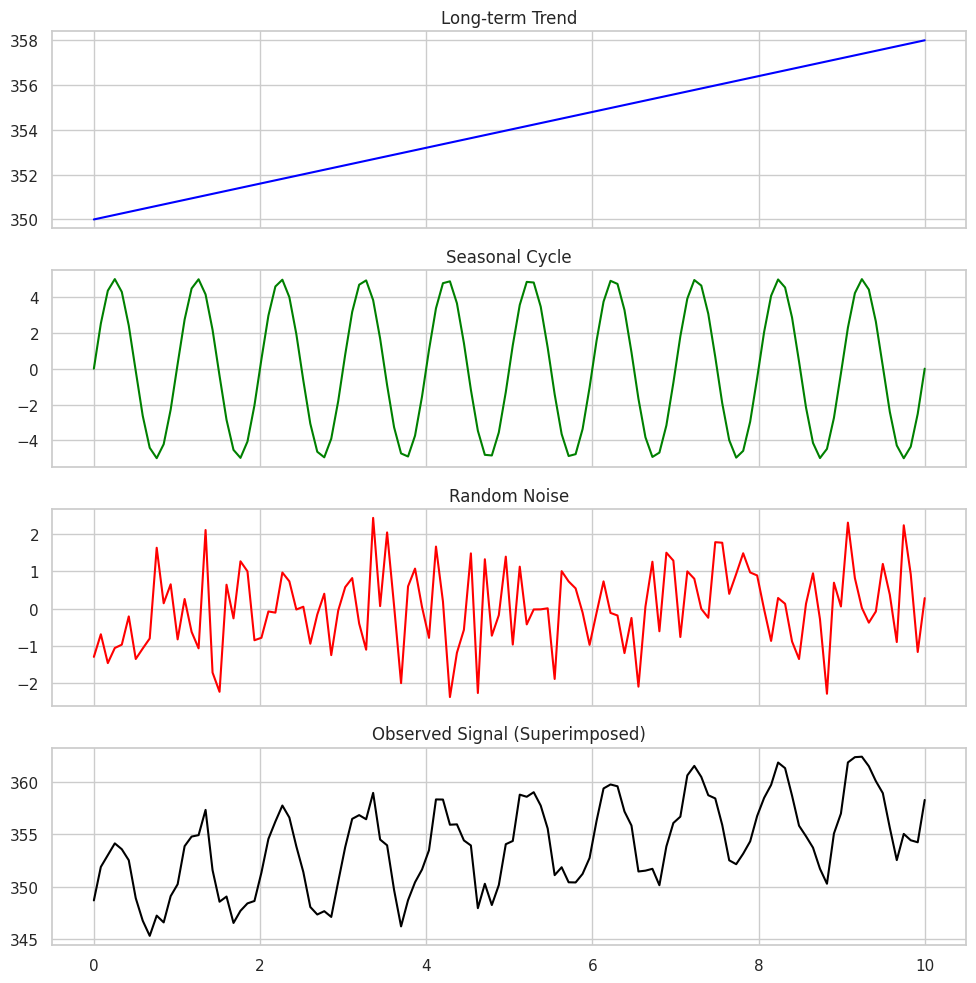

In [8]:
time = np.linspace(0, 10, 120) # 10 years of monthly data

# Create components
trend = 0.8 * time + 350
seasonality = 5 * np.sin(2 * np.pi * time)
noise = np.random.normal(0, 1.2, len(time))

# Combine (Superposition)
observed = trend + seasonality + noise

# Plotting the breakdown
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axes[0].plot(time, trend, color='blue'); axes[0].set_title('Long-term Trend')
axes[1].plot(time, seasonality, color='green'); axes[1].set_title('Seasonal Cycle')
axes[2].plot(time, noise, color='red'); axes[2].set_title('Random Noise')
axes[3].plot(time, observed, color='black', lw=1.5); axes[3].set_title('Observed Signal (Superimposed)')
plt.tight_layout()
plt.show()

### 2.2 Detrending and Differencing
To analyze the cyclical parts of a series, we often need to remove the trend. This makes the series **stationary** (statistical properties don't change over time).
1. **Detrending:** Subtracting a linear regression fit.
2. **Differencing:** Subtracting the previous value from the current value ($Y_t - Y_{t-1}$).

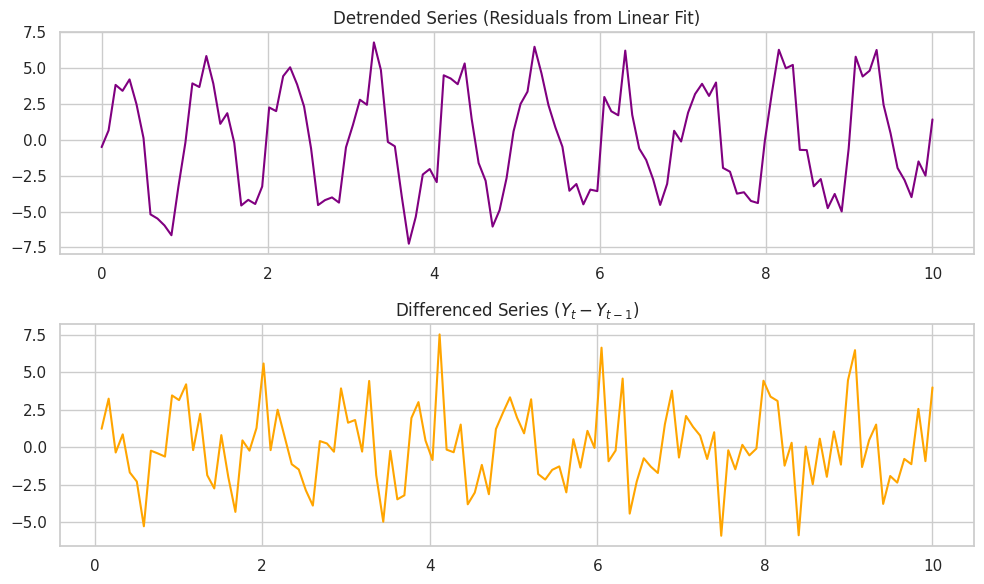

In [5]:
# 1. Detrending using a simple linear subtraction
slope, intercept, r_val, p_val, std_err = stats.linregress(time, observed)
fit = slope * time + intercept
detrended = observed - fit

# 2. Differencing
differenced = pd.Series(observed).diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(time, detrended, color='purple')
ax1.set_title("Detrended Series (Residuals from Linear Fit)")
ax2.plot(time, differenced, color='orange')
ax2.set_title("Differenced Series ($Y_t - Y_{t-1}$)")
plt.tight_layout()
plt.show()

### 2.3 Autocorrelation (ACF)
Autocorrelation measures how a data point correlates with a "lagged" version of itself. This is critical for identifying repeating patterns (cycles) and "memory" in a system.

<Figure size 1000x500 with 0 Axes>

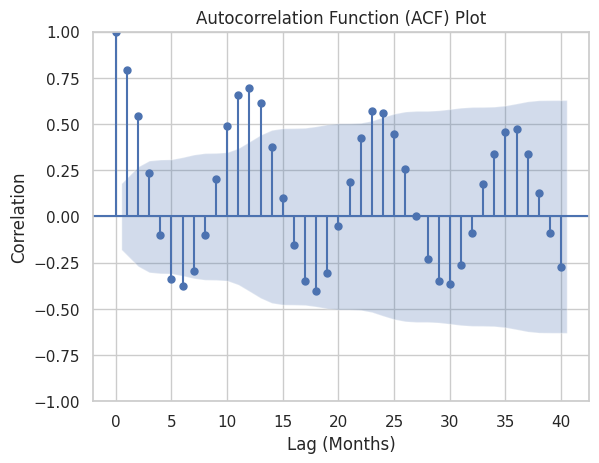

In [6]:
# Plotting Autocorrelation for the Keeling Curve simulation
plt.figure(figsize=(10, 5))
plot_acf(observed, lags=40)
plt.title("Autocorrelation Function (ACF) Plot")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")
plt.show()
# Note the peaks at 12, 24, and 36 months—this indicates a clear annual cycle!

### 2.4 Cross-Correlation (Cause and Effect)
Cross-correlation (CCF) is used to find the lag between two different series.
**Earth Science Example:** How many days does it take for rainfall in the mountains to show up as a discharge spike in a downstream river?

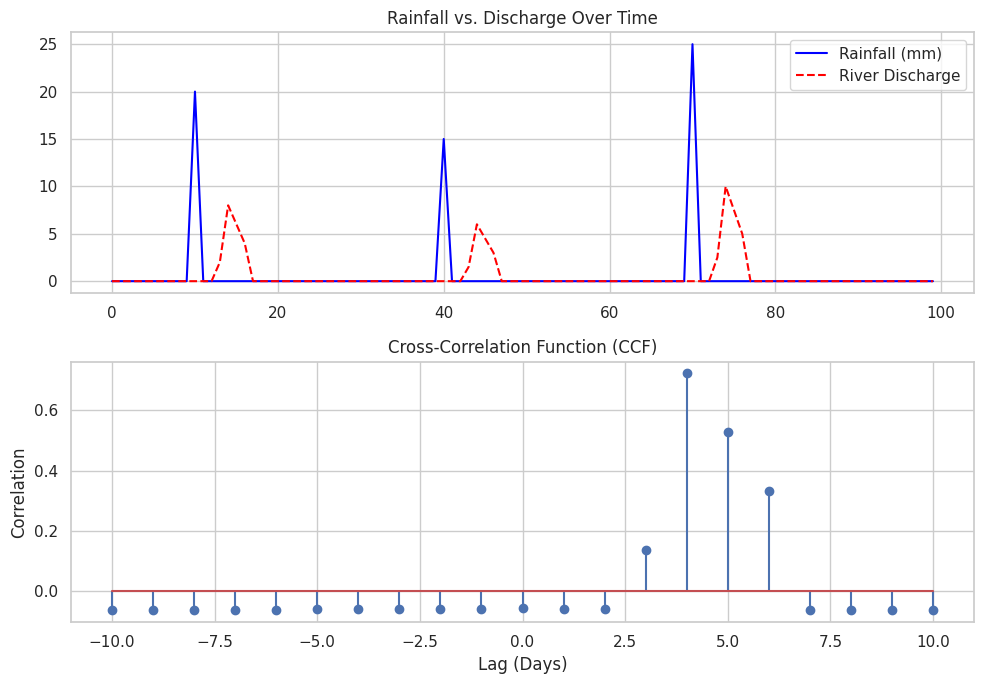

In [7]:
# Simulate a 100-day window
days = np.arange(100)
rain = np.zeros(100)
rain[[10, 40, 70]] = [20, 15, 25] # Three major storm events

# Discharge is a delayed and smoothed version of rain
# Let's say there is a 4-day lag
discharge = np.roll(np.convolve(rain, [0.1, 0.4, 0.3, 0.2], mode='same'), 4)

# Calculate Cross-Correlation
lags = np.arange(-10, 11)
ccf = [pd.Series(discharge).corr(pd.Series(rain).shift(lag)) for lag in lags]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax1.plot(days, rain, label='Rainfall (mm)', color='blue')
ax1.plot(days, discharge, label='River Discharge', color='red', linestyle='--')
ax1.legend(); ax1.set_title("Rainfall vs. Discharge Over Time")

ax2.stem(lags, ccf)
ax2.set_title("Cross-Correlation Function (CCF)")
ax2.set_xlabel("Lag (Days)")
ax2.set_ylabel("Correlation")
plt.tight_layout()
plt.show()